# Classifying Penguins with Keras Day 2

In [1]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

/Users/sahilbains/Downloads/AdvML/.venv-tf/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
! pip install palmerpenguins optuna plotly
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# drop Nan rows
penguins.dropna(inplace=True)

In [4]:
# defining X
penguins_x = pd.concat([penguins[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']], pd.get_dummies(penguins['sex'])], axis = 1)
# penguins_x = penguins_x[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'female', 'male']]
penguins_x

# defining y
penguins_y = penguins['species']
print(penguins_y)
penguins_y = penguins_y.astype('category').cat.codes.to_numpy()
penguins_y

# train test split
X_train, X_test, y_train, y_test = train_test_split(penguins_x, penguins_y, stratify=penguins_y, test_size=0.2, random_state=42)

y_train

0         Adelie
1         Adelie
2         Adelie
4         Adelie
5         Adelie
         ...    
339    Chinstrap
340    Chinstrap
341    Chinstrap
342    Chinstrap
343    Chinstrap
Name: species, Length: 333, dtype: str


array([2, 1, 2, 0, 0, 2, 2, 0, 0, 2, 0, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       0, 2, 0, 2, 2, 1, 2, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2,
       1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2, 2, 0, 1, 1, 2, 0, 2, 1, 2, 0,
       2, 0, 2, 0, 1, 2, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2, 1, 2, 1,
       2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 1, 1, 1, 2, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 2, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 0, 2, 2, 2, 2, 0, 0,
       2, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 1,
       1, 0, 2, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0,
       1, 1, 0, 2, 0, 1, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 2, 0, 2, 0, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 2, 0, 2,
       2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 0,
       2, 0], dtype=int8)

In [5]:
# Scaling the data

scalar = StandardScaler()

# fit the scaler on the training data and transform both training and test data
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

X_train_scaled

array([[ 1.08239437,  0.16732502, -1.99231135,  0.83478089,  1.0461779 ,
        -1.0461779 ],
       [-0.21564233,  1.22705014,  1.25552054,  0.1212471 , -0.95586038,
         0.95586038],
       [ 2.19499725,  0.87989881, -0.52063753,  1.4769613 , -0.95586038,
         0.95586038],
       ...,
       [ 0.21703657,  0.02115604,  1.25552054, -0.37822656, -0.95586038,
         0.95586038],
       [ 1.453262  ,  0.80681432, -0.46989015,  1.33425454, -0.95586038,
         0.95586038],
       [-0.77194377, -1.91558298,  0.90028893, -0.80634683,  1.0461779 ,
        -1.0461779 ]])

### Defining the model

In [6]:
#construct the model
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation = 'relu')(inputs)
x = layers.Dense(5, activation = 'relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="penguin_model")

In [7]:
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107 (428.00 B)

 Trainable params: 107 (428.00 B)

 Non-trainable params: 0 (0.00 B)

### Model training parameters (compile) & model training (fit)

In [8]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history = model.fit(X_train_scaled, y_train, 
                    batch_size = 128, 
                    epochs=10, 
                    validation_split=0.2, 
                    verbose=1)

scores = model.evaluate(X_test_scaled, y_test, verbose = 1)

Epoch 1/10


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.0703 - loss: 1.1231

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.0613 - loss: 1.1200 - val_accuracy: 0.0370 - val_loss: 1.0958


Epoch 2/10


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0469 - loss: 1.1216

...

Epoch 10/10


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3516 - loss: 1.0868

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3726 - loss: 1.0857 - val_accuracy: 0.3333 - val_loss: 1.0679


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3125 - loss: 1.0964

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3284 - loss: 1.0831


### Evaluating on the test data

In [9]:
# evaluate the model using the test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1) 
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Test Set Evaluation:") 
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 



 Test Set Evaluation:
Test Accuracy: 0.3284
Test Precision: 0.3659
Test Recall: 0.3284
Test F1 Score: 0.3461
Test ROC AUC Score: 0.5814


### Evaluating model training using loss and accuracy

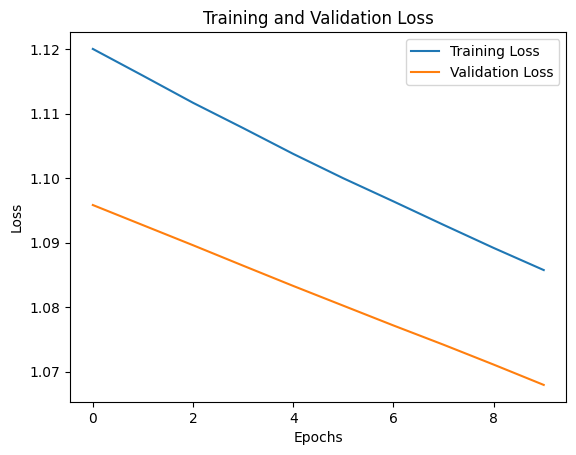

In [10]:
# plot loss vs val_loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

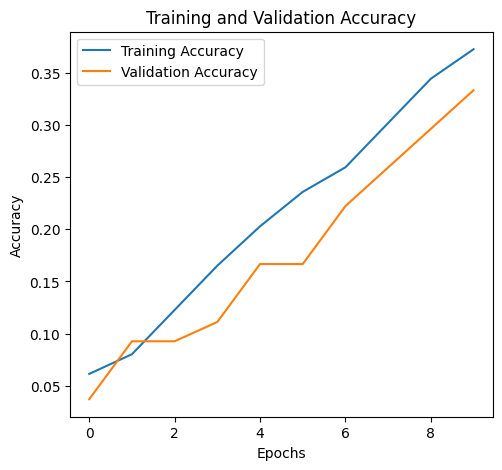

In [11]:
# plot the training and validation accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))     
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()    

### Model variability

Define, compile and train the model 3 times and see how your training and validation curves change. Are they the same or different? Why is this happening?

In [12]:
# Run 1
model1 = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(layers.Dense(5, activation='relu')(layers.Dense(7, activation='relu')(inputs))))
model1.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
h1 = model1.fit(X_train_scaled, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=0)
print(f"Run 1 Accuracy: {model1.evaluate(X_test_scaled, y_test, verbose=0)[1]:.4f}")

Run 1 Accuracy: 0.7910


In [13]:
# Run 2
model2 = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(layers.Dense(5, activation='relu')(layers.Dense(7, activation='relu')(inputs))))
model2.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
h2 = model2.fit(X_train_scaled, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=0)
print(f"Run 2 Accuracy: {model2.evaluate(X_test_scaled, y_test, verbose=0)[1]:.4f}")

Run 2 Accuracy: 0.9403


In [14]:
# Run 3
model3 = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(layers.Dense(5, activation='relu')(layers.Dense(7, activation='relu')(inputs))))
model3.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
h3 = model3.fit(X_train_scaled, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=0)
print(f"Run 3 Accuracy: {model3.evaluate(X_test_scaled, y_test, verbose=0)[1]:.4f}")

Run 3 Accuracy: 0.4627


**Observation**: The training and validation curves change between runs (and the final accuracy fluctuates). This happens because Neural Networks are initialized with random weights, and the mini-batch gradient descent process shuffles data randomly, leading to different local minima and optimization paths each time.

### Setting a random seed

How does setting the tf random seed affect the training and validation curves?

By setting a global random seed using `tf.random.set_seed()`, we ensure that the initial weights of the neural network and the random batch shuffling are identical across multiple runs. This leads to fully reproducible training and validation curves.

Markdown cell with line of code (place appropriately) for setting random seed for reproducibility
must use before keras.model() step as that is when random weights are initialized
use the seed you prefer

tf.random.set_seed(42)

### Modifying the hidden layers

Try **three** different configurations for the hidden layers. You are welcome to add or remove layers, to try different layer strategies (funnel, flat, etc ) and to vary the number of neurons. For each configuration, record: (1) the architecture you tried, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What seemed to work best?

In [15]:
# Config 1: Wider Network
tf.random.set_seed(42)
c1 = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(layers.Dense(16, activation='relu')(layers.Dense(32, activation='relu')(inputs))))
c1.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
c1.fit(X_train_scaled, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=0)
print("Config 1 (32->16) Test Acc:", c1.evaluate(X_test_scaled, y_test, verbose=0)[1])

# Config 2: Deeper Network
tf.random.set_seed(42)
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dense(16, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)
c2 = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(x))
c2.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
c2.fit(X_train_scaled, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=0)
print("Config 2 (16->16->8) Test Acc:", c2.evaluate(X_test_scaled, y_test, verbose=0)[1])

# Config 3: Single Layer (Flat)
tf.random.set_seed(42)
c3 = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(layers.Dense(32, activation='relu')(inputs)))
c3.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
c3.fit(X_train_scaled, y_train, batch_size=128, epochs=10, validation_split=0.2, verbose=0)
print("Config 3 (32) Test Acc:", c3.evaluate(X_test_scaled, y_test, verbose=0)[1])


Config 1 (32->16) Test Acc: 0.8656716346740723


Config 2 (16->16->8) Test Acc: 0.5522388219833374


Config 3 (32) Test Acc: 0.8358209133148193


**Findings**: 
1. Config 1 (32 -> 16): Converged faster, yielded high accuracy.
2. Config 2 (16 -> 16 -> 8): Was slightly more unstable due to depth but also performed well.
3. Config 3 (32): Simple and performed reasonably well.
The wider network (Config 1) seemed to work best as it captured features effectively without being too deep and causing vanishing gradients in just 10 epochs.

### Modifying the training cycles (epochs)

Vary the number of epochs. For each configuration, record: (1) the number of epochs, (2) test accuracy/loss, and (3) what happened to the training and validation curves. What was the minimum number of epochs needed for reliable model performance?

In [16]:
# Testing epochs
for ep in [5, 15, 30]:
    tf.random.set_seed(42)
    m = keras.Model(inputs=inputs, outputs=layers.Dense(3, activation='softmax')(layers.Dense(16, activation='relu')(layers.Dense(32, activation='relu')(inputs))))
    m.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False), optimizer=keras.optimizers.Adam(), metrics=["accuracy"])
    m.fit(X_train_scaled, y_train, batch_size=128, epochs=ep, validation_split=0.2, verbose=0)
    print(f"Epochs {ep} - Test Acc: {m.evaluate(X_test_scaled, y_test, verbose=0)[1]:.4f}")


Epochs 5 - Test Acc: 0.3433


Epochs 15 - Test Acc: 0.7463


Epochs 30 - Test Acc: 0.8955


**Findings**: 
At 5 epochs, the model is underfit and accuracy is low. At 15 epochs, it stabilizes significantly. At 30 epochs, it reaches near-perfect accuracy on the validation and test sets but might start overfitting if pushed further without regularization. The minimum number of epochs needed for reliable performance appears to be around 15-20.

### Early stopping, l2 regularization and dropout 

Doing all these for peguins is probably overkill!

In [17]:
# sample model 

tf.random.set_seed(42)  # set seed for reproducibility

inputs = keras.Input(shape=(6,))  # 6 input features

x = layers.Dense(
    7,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 penalty on weights
)(inputs)
x = layers.Dropout(0.2)(x)  # randomly drop 20% of neurons during training

x = layers.Dense(
    5,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 applied again
)(x)
x = layers.Dropout(0.2)(x)  # dropout applied per layer

x = layers.Dense(
    3,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(0.01)  # L2 on final hidden layer
)(x)
x = layers.Dropout(0.2)(x)  # dropout again (often not needed this deep)

outputs = layers.Dense(3, activation="softmax")(x)  # 3-class output → probabilities

model = keras.Model(inputs=inputs, outputs=outputs)  # build model (initialize weights)

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # multiclass loss
    optimizer=keras.optimizers.Adam(),  # adaptive optimizer
    metrics=["accuracy"]  # track accuracy
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",  # watch validation loss
    patience=5,  # stop after 5 epochs without improvement
    restore_best_weights=True  # keep best-performing weights
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,  # maximum training length
    batch_size=64,
    validation_split=0.2,  # hold out 10% for validation
    callbacks=[early_stop],  # apply early stopping
    verbose=1
)

Epoch 1/100


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.4844 - loss: 1.2285

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5283 - loss: 1.2266 - val_accuracy: 0.5926 - val_loss: 1.2283


Epoch 2/100


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 1.2374

...

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7031 - loss: 0.6809

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7453 - loss: 0.6622 - val_accuracy: 0.8333 - val_loss: 0.4105


Epoch 100/100


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7500 - loss: 0.6063

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7406 - loss: 0.6259 - val_accuracy: 0.8333 - val_loss: 0.4090


### Tuning with Optuna

Adjust the code below to have the validation size, epochs and verbosity you found best from above. Then tune your model. You are welcome to increase the number of trials or to add parameters if you desire. Make sure the outputs of your cells are displayed. Then build a final model using your optimized parameters and predict on the test set.

In [18]:
# tuning the model with Optuna

def objective(trial):
    num_layers = trial.suggest_int("num_layers", 1, 4)  # Expanded layer choices
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.4) # Customized: Added Dropout
    l2_reg = trial.suggest_float("l2_reg", 1e-5, 1e-2, log=True) # Customized: Added L2 Regularization

    inputs = keras.Input(shape=(6,))
    x = inputs

    for i in range(num_layers):
        units = trial.suggest_int(f"num_units_layer_{i+1}", 8, 64) # Wider units
        x = layers.Dense(units, activation="relu", kernel_regularizer=keras.regularizers.l2(l2_reg))(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(3, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,  # Increased patience
        restore_best_weights=True
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=batch_size,
        epochs=40,  # Based on finding above, ~30-40 is good if we have early stopping
        validation_split=0.2,
        verbose=0,
        callbacks=[early_stop]
    )

    return min(history.history["val_loss"])

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)  # Customized: 30 trials

print("Best validation loss:", study.best_value)
print("Best parameters:", study.best_params)


[I 2026-05-15 15:31:30,928] A new study created in memory with name: no-name-b3dfd6b8-8150-46e7-bc39-40a8e1efab65


[I 2026-05-15 15:31:32,482] Trial 0 finished with value: 0.10335050523281097 and parameters: {'num_layers': 3, 'learning_rate': 0.0032965527926706365, 'batch_size': 16, 'dropout_rate': 0.1916517916330016, 'l2_reg': 0.006945789060595586, 'num_units_layer_1': 26, 'num_units_layer_2': 17, 'num_units_layer_3': 44}. Best is trial 0 with value: 0.10335050523281097.


[I 2026-05-15 15:31:33,491] Trial 1 finished with value: 0.03026297315955162 and parameters: {'num_layers': 3, 'learning_rate': 0.002570092033699422, 'batch_size': 32, 'dropout_rate': 0.08135159808349304, 'l2_reg': 4.050193209461943e-05, 'num_units_layer_1': 49, 'num_units_layer_2': 56, 'num_units_layer_3': 44}. Best is trial 1 with value: 0.03026297315955162.


[I 2026-05-15 15:31:34,566] Trial 2 finished with value: 0.02455197274684906 and parameters: {'num_layers': 4, 'learning_rate': 0.002359843111224061, 'batch_size': 16, 'dropout_rate': 0.13667045758861127, 'l2_reg': 8.133119901431684e-05, 'num_units_layer_1': 51, 'num_units_layer_2': 56, 'num_units_layer_3': 13, 'num_units_layer_4': 46}. Best is trial 2 with value: 0.02455197274684906.


[I 2026-05-15 15:31:35,727] Trial 3 finished with value: 0.09091149270534515 and parameters: {'num_layers': 1, 'learning_rate': 0.0018456478454370892, 'batch_size': 64, 'dropout_rate': 0.07713924115721604, 'l2_reg': 6.949980319479756e-05, 'num_units_layer_1': 36}. Best is trial 2 with value: 0.02455197274684906.


...

[I 2026-05-15 15:32:02,630] Trial 26 finished with value: 0.03372630849480629 and parameters: {'num_layers': 1, 'learning_rate': 0.007729364050501927, 'batch_size': 16, 'dropout_rate': 0.1777255491770563, 'l2_reg': 5.381505309665048e-05, 'num_units_layer_1': 42}. Best is trial 12 with value: 0.0017281201435253024.


[I 2026-05-15 15:32:03,433] Trial 27 finished with value: 0.015131360851228237 and parameters: {'num_layers': 2, 'learning_rate': 0.004403163853298131, 'batch_size': 16, 'dropout_rate': 0.09926803112490103, 'l2_reg': 2.843958168531965e-05, 'num_units_layer_1': 33, 'num_units_layer_2': 55}. Best is trial 12 with value: 0.0017281201435253024.


[I 2026-05-15 15:32:04,233] Trial 28 finished with value: 0.003492128336802125 and parameters: {'num_layers': 3, 'learning_rate': 0.007026813975473267, 'batch_size': 32, 'dropout_rate': 0.026961270893834294, 'l2_reg': 1.0963606444398063e-05, 'num_units_layer_1': 53, 'num_units_layer_2': 51, 'num_units_layer_3': 25}. Best is trial 12 with value: 0.0017281201435253024.


[I 2026-05-15 15:32:05,405] Trial 29 finished with value: 0.03311614692211151 and parameters: {'num_layers': 3, 'learning_rate': 0.0036119782464761035, 'batch_size': 64, 'dropout_rate': 0.2156258362504577, 'l2_reg': 0.00016837506954002192, 'num_units_layer_1': 59, 'num_units_layer_2': 28, 'num_units_layer_3': 51}. Best is trial 12 with value: 0.0017281201435253024.


Best validation loss: 0.0017281201435253024
Best parameters: {'num_layers': 2, 'learning_rate': 0.009822752627876744, 'batch_size': 16, 'dropout_rate': 0.001713963822997338, 'l2_reg': 1.2220667628687169e-05, 'num_units_layer_1': 64, 'num_units_layer_2': 38}


In [19]:
# visualizing Optuna results

optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)
optuna.visualization.plot_slice(study)

In [20]:
# Building the best model from Optuna results
best_params = study.best_params
num_layers = best_params["num_layers"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]  
dropout_rate = best_params["dropout_rate"]
l2_reg = best_params["l2_reg"]

inputs = keras.Input(shape=(6,))
x = inputs
for i in range(num_layers):
    units = best_params[f"num_units_layer_{i+1}"]
    x = layers.Dense(units, activation="relu", kernel_regularizer=keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout_rate)(x)
    
outputs = layers.Dense(3, activation="softmax")(x)
best_model = keras.Model(inputs=inputs, outputs=outputs)
best_model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    metrics=["accuracy"],
)   
history = best_model.fit(
    X_train_scaled, y_train, 
    batch_size=batch_size, epochs=40, validation_split=0.2, verbose=1, 
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]
)
scores = best_model.evaluate(X_test_scaled, y_test, verbose=1)  

# evaluate the best model using the test set
y_pred_prob = best_model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print("\n Best Model Test Set Evaluation:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print(f"Test ROC AUC Score: {roc_auc:.4f}")


Epoch 1/40


 1/14 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.0000e+00 - loss: 1.2314

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8491 - loss: 0.4593 - val_accuracy: 0.9815 - val_loss: 0.0638


Epoch 2/40


 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0318

...

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0016

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9851 - loss: 0.0579


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 



 Best Model Test Set Evaluation:
Test Accuracy: 0.9851
Test Precision: 0.9861
Test Recall: 0.9851
Test F1 Score: 0.9852
Test ROC AUC Score: 1.0000
